---
## Step 1-Upload Dataset

In [62]:
# ── Upload the zip file from your computer ───
# Run this cell, a "Choose Files" button will appear, select feedback-prize-2021.zip

from google.colab import files

print("Click the 'Choose Files' button below and select feedback-prize-2021.zip")
print("Wait for the upload to complete before running the next cell.")
print()

uploaded = files.upload()

# Confirm upload
import os
for fname in uploaded.keys():
    size_mb = os.path.getsize(fname) / (1024 * 1024)
    print(f" Uploaded: {fname}  ({size_mb:.1f} MB)")


Click the 'Choose Files' button below and select feedback-prize-2021.zip
Wait for the upload to complete before running the next cell.



Saving feedback-prize-2021.zip to feedback-prize-2021 (2).zip
 Uploaded: feedback-prize-2021 (2).zip  (32.4 MB)


---
## Step 2-Unzip the Dataset

In [63]:
import zipfile, os
from pathlib import Path

# ── Unzip the uploaded file ───────────
ZIP_NAME = "feedback-prize-2021.zip"
DATA_DIR = Path("data")

if not DATA_DIR.exists():
    print(f"Extracting {ZIP_NAME}... (this may take 1-2 minutes)")
    with zipfile.ZipFile(ZIP_NAME, 'r') as z:
        z.extractall("data")
    print("Extraction complete")
else:
    print("data/ folder already exists-skipping extraction")

print()
print("Contents of data/ folder:")
print(os.listdir("data"))


data/ folder already exists-skipping extraction

Contents of data/ folder:
['sample_submission.csv', 'train', 'test', 'train.csv']


In [64]:
# ── Verify all required files are present ─────────
DATA_DIR  = Path("data")
ESSAY_DIR = DATA_DIR / "train"

train_csv = DATA_DIR / "train.csv"

assert train_csv.exists(),  f" train.csv not found-check your zip extraction"
assert ESSAY_DIR.exists(),  f" train/ folder not found-check your zip extraction"

essay_files = list(ESSAY_DIR.glob("*.txt"))

print(f" train.csv found")
print(f" train/folder found-{len(essay_files):,} essay .txt files")
print()
print(" Data is ready! Run the next cells.")


 train.csv found
 train/folder found-15,594 essay .txt files

 Data is ready! Run the next cells.


---
## Section 1-Install Libraries & Imports

In [65]:
# ── Install SHAP (everything else is pre-installed in Colab) ─────────────────
!pip install shap -q
print("Libraries ready ")


Libraries ready 


In [66]:
# ── Fix all random seeds for reproducibility ──────────────────────────────────
import random, os, warnings
SEED = 42
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')

# ── Core ──────────────────────────────────────────────────
import numpy as np
np.random.seed(SEED)
import pandas as pd
from pathlib import Path
from scipy.sparse import hstack

# ── Visualisation ───────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
PALETTE = sns.color_palette('tab10')

# ── Scikit-learn: preprocessing ────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Scikit-learn: models ──────────────────────────────────
from sklearn.dummy        import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm          import LinearSVC
from sklearn.ensemble     import RandomForestClassifier

# ── Scikit-learn: validation & metrics ───────────────────────
from sklearn.model_selection import StratifiedKFold, cross_validate,GroupKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
    accuracy_score, balanced_accuracy_score
)
from sklearn.inspection import permutation_importance

# ── SHAP ────────────────────────────────────
try:
    import shap
    HAS_SHAP = True
    print("SHAP available ")
except ImportError:
    HAS_SHAP = False
    print("SHAP not available-permutation importance will be used instead")

# ── Version report ────────────────────────────────────────────────────────────
import sklearn, matplotlib, seaborn, sys
print()
print("Library Versions:")
for name, lib in [("python",       sys),
                  ("numpy",        np),
                  ("pandas",       pd),
                  ("scikit-learn", sklearn),
                  ("matplotlib",   matplotlib),
                  ("seaborn",      seaborn)]:
    ver = sys.version.split()[0] if name == "python" else lib.__version__
    print(f"  {name:<15} {ver}")


SHAP available 

Library Versions:
  python          3.12.12
  numpy           2.0.2
  pandas          2.2.2
  scikit-learn    1.6.1
  matplotlib      3.10.0
  seaborn         0.13.2


## Section 2-Problem Framing

### 2.1 What Is This Dataset?
In this **Feedback Prize-Evaluating Student Writing** competition has **~15,000 student argumentative essays** as plain `.txt` files and **`train.csv`** - has following columns which is shown as in table including all features, data type and its description:

| Column | Data Type | Interpretation |
|---|---|---|
| `id`(i.e. essay id) | string | Unique span ID for essay |
| `discourse_start` | int | Whole number indicating starting character offset of span |
| `discourse_end` | int | Whole number indicating ending character offset of span|
| `discourse_text` | string | Text string representing actual content of span|
| `discourse_type` | string | **TARGET-7 discourse categories** |
| `predictionstring` | string | Token positions- **excluded to avoid leakage** |

### 2.2 Target Variable
```
discourse_type is taeget variable and it belongs to 7 categories which are Lead, Position, Claim,
Counterclaim,Rebuttal, Evidence,
Concluding Statement
```

### 2.3 Task Definition
## Task and Scope of Project

The goal of this research is to classify sections of student essays into predetermined discourse classes by employing machine learning strategies. In the corpus provided, student essays have been subdivided into smaller components, referred to as discourse spans, which represent different elements of argumentative writing. For the dataset of student essays there are seven different types of argumentative writing components, including Lead, Position, Claim, Evidence, Counter Claim, Rebuttal, and Concluding Statement.

The task at hand can be classified as a **textual multi-class classification problem**; the result will be a model that learns the patterns in both the language and structural features of these spans so that you will be able to classify the discourse function for a given segment of an essay.

> **Multi-Class Classification: Given a set of features from a discourse span, predict which of the seven types of discourse it is.**

**Unit of Measure:** One row corresponds to a single annotated discourse span of an essay.

### 2.4 Metric Choice & Rationale

Considering that there is an imbalance in the dataset, it is necessary to evaluate all of these types of discourse types according to an equitable fashion. For instance, two categories (i.e., **Evidence** and **Claim**) occur at far greater frequencies than two categories (i.e., **Counterclaim** and **Rebuttal**) do.

To account for this, the evaluation metric that has been used for the main evaluation of this project is the **Macro F1** score. The **Macro F1** score calculates the F1 score for each class independently and then averages those scores across the classes, thus allowing for weighting of classes based upon their frequency. This also allows less frequent classes to receive as much weighting as more frequent classes.

To aid in evaluation of the model's performance, the following additional avenues have been explored to better understand the model. Although included in this evaluation is **Accuracy**, because it has an intuitive value, it does, however, have potential for being skewed in the presence of an imbalance among the classes. Additionally, as part of error analysis, **Precision and Recall for each class** are also examined to identify areas where the model struggles or performs well. In addition, the **Balanced Accurate** score will be presented as an additional metric to provide a more accurate evaluation than using **standard Accuracy**, because this metric adjusts for differences frequency of classes and therefore results in more equal evaluations across classes than using **standard Accuracy** results in.

### 2.5 Data Leakage Risks & Mitigations

|### 2.5 Data Leakage and Mitigation Measures

The following measures have been taken to mitigate risks associated with potential data leakage during the development of the models.

First, the predictionstring feature was excluded from the feature set because it contains token positional information that directly mirrors the original essay structure; thus, by using the predictionstring feature, the model may potentially identify where a discourse span will reside within an essay and as a result, identify shortcut learning instead of building more meaningful or generalizable learning.

Second, there are multiple discourse spans per essay; since there are multiple spans per essay, all spans belong to their own individual writing style and have the same context as others in the same essay. Thus, there are no essay matching learned behaviours during training between the training and test data because the dataset was split at the essay level based upon essay ID so that the same essay cannot cross-test/train.

Finally, some feature representations such as prev_type or next_type can introduce leakage across either split if the features have relied on information from another split’s span. Therefore, all contextual ordering was computed solely within the essay and no information from the test data was utilized while training for any of the contextual ordering.

### 2.6 Risks & Potential Impact

If the model can provide automated writing feedback for students then predictions that are incorrect can assist students with how or if they revise their essay. However not accurately predicting lower-performing classes such as Counterclaim and Rebuttal can lead to providing students with incomplete or inaccurate feedback. There are also differences in the way the model predicts between short vs long essays, which implies that shorter essays will not be as accurately predicted. Therefore any type of public use of this model will require defining confidence levels, performing subgroup fairness audit checks on these confidence levels and providing human oversight to prevent educational harm from occurring.

### 2.7 Assumptions of Modeling

In the development of the model for this project, we have made assumptions that are related to the combination of structural and text features as predictors for the discourse type of a span.

The following are a list of the assumptions made when creating the model:

1. Each discourse span is treated as its own independent example, even though multiple spans are often part of the same essay (sequentially).
2. The labels provided for each discourse span in the dataset will be considered to be accurate. While there may be overlap between categories (e.g., between *Claim* and *Position*), they can be used as labels to create a model.
3. The dataset used to create this model primarily represents middle-school argumentative writing and, therefore, any results generated from this dataset should be interpreted in this context.

---
## Section 3-Load Data

In [67]:
# ── Load train.csv ────────────────────────────────────────────────────────────
DATA_DIR  = Path("data")
ESSAY_DIR = DATA_DIR / "train"

df = pd.read_csv(DATA_DIR / "train.csv")

print(f"Total spans (rows) : {len(df):,}")
print(f"Total essays       : {df['id'].nunique():,}")
print(f"Columns            : {list(df.columns)}")
print()
df.head(3)


Total spans (rows) : 144,293
Total essays       : 15,594
Columns            : ['id', 'discourse_id', 'discourse_start', 'discourse_end', 'discourse_text', 'discourse_type', 'discourse_type_num', 'predictionstring']



,id,discourse_id,discourse_start,discourse_end,discourse_text,discourse_type,discourse_type_num,predictionstring
0,423A1CA112E2,1.622628e+12,8.0,229.0,Modern humans today are always on their phone....,Lead,Lead 1,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...
1,423A1CA112E2,1.622628e+12,230.0,312.0,They are some really bad consequences when stu...,Position,Position 1,45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
2,423A1CA112E2,1.622628e+12,313.0,401.0,Some certain areas in the United States ban ph...,Evidence,Evidence 1,60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75


## Feature Description

### data

The data will contain labelled discourse spans from student essays. The primary features used in this project are:

- **essay_id**-identifies which essay the span is part of, preventing data from leaking during training and testing splits.
- **discourse_text**-the actual text of the span, to extract text features using TF-IDF.
- **discourse_start**-the position of where the span starts within the essay, allowing for position-based features to be computed.
- **discourse_type**-the target variable used to represent each of the 7 discourse categories.
---

### Engineered Structural Features

TIn addition to measuring how essays are structured, we created a number of extra features, including:

* rel_pos, which tells us what the relative position of that span would be in an essay (0 represents start and 1 represents end);
* norm_rank, which tells us the position of that span in an essay;
* in both instances, we have captured the length of each of those spans in terms of both word count and character count;
* counting the total number of sentences contained in each of these spans;
* counting the overall length of all essays by measuring the total number of words in each essay;
* indicating whether or not that span begins with a signal word (i.e., “however”, “therefore”) used to connect discourse within each of these essays; and
* grouping these spans into three groups based on whether they occur early, mid-point, or late in the text as a whole.

---

### Text Features

In order to discover significant words and phrases within **discourse_text**, TF-IDF was used on individual words (unigrams) and pairs of words (bigrams).  

Thus, through the use of both **text features** (the words themselves) and **structural features** (where in the essay the words are used), this model will learn both what the text means and where it appears within the overall essay.

In [68]:
# Check what columns actually exist in your CSV
print("Columns in your CSV:")
print(df.columns.tolist())
print()
print("First 2 rows:")
print(df.head(2))

Columns in your CSV:
['id', 'discourse_id', 'discourse_start', 'discourse_end', 'discourse_text', 'discourse_type', 'discourse_type_num', 'predictionstring']

First 2 rows:
             id  discourse_id  discourse_start  discourse_end  \
0  423A1CA112E2  1.622628e+12              8.0          229.0   
1  423A1CA112E2  1.622628e+12            230.0          312.0   

                                      discourse_text discourse_type  \
0  Modern humans today are always on their phone....           Lead   
1  They are some really bad consequences when stu...       Position   

  discourse_type_num                                   predictionstring  
0             Lead 1  1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...  
1         Position 1       45 46 47 48 49 50 51 52 53 54 55 56 57 58 59  


In [69]:
# ── Load all essay text files ─────────────────────────────────────────────────
def read_essay(id):
    p = ESSAY_DIR / f"{id}.txt"
    return p.read_text(encoding="utf-8") if p.exists() else ""

essay_texts = {eid: read_essay(eid) for eid in df["id"].unique()}

loaded = sum(1 for t in essay_texts.values() if t)
print(f"Essays loaded : {loaded:,} / {len(essay_texts):,}")
print(f"Sample essay length : {len(list(essay_texts.values())[0]):,} characters")


Essays loaded : 15,594 / 15,594
Sample essay length : 2,030 characters


In [70]:
# ── Check target variable
print("Target class counts:")
print(df["discourse_type"].value_counts())
print()
print(f"Missing in discourse_type : {df['discourse_type'].isna().sum()}")
print(f"Missing in discourse_text : {df['discourse_text'].isna().sum()}")


Target class counts:
discourse_type
Claim                   50208
Evidence                45702
Position                15419
Concluding Statement    13505
Lead                     9305
Counterclaim             5817
Rebuttal                 4337
Name: count, dtype: int64

Missing in discourse_type : 0
Missing in discourse_text : 0


---
## Section 4-Exploratory Data Analysis (EDA)

6 labeled visuals, each tied to a specific hypothesis.

### Data Quality Check


In [71]:
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)
print(f"Total rows            : {len(df):,}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows        : {df.duplicated().sum()}")
empty = (df["discourse_text"].str.strip() == "").sum()
print(f"Empty discourse texts : {empty}")
print(f"Unique discourse types: {df['discourse_type'].nunique()}")
print(f"Unique essays         : {df['id'].nunique():,}")
print("=" * 50)
print("\n No critical data quality issues found.")


DATA QUALITY REPORT
Total rows            : 144,293

Missing values per column:
id                    0
discourse_id          0
discourse_start       0
discourse_end         0
discourse_text        0
discourse_type        0
discourse_type_num    0
predictionstring      0
dtype: int64

Duplicate rows        : 0
Empty discourse texts : 0
Unique discourse types: 7
Unique essays         : 15,594

 No critical data quality issues found.


### Figure 1-Class Distribution
**Hypothesis:** The dataset is imbalanced-some discourse types are much more common than others, making Macro F1 the right metric.

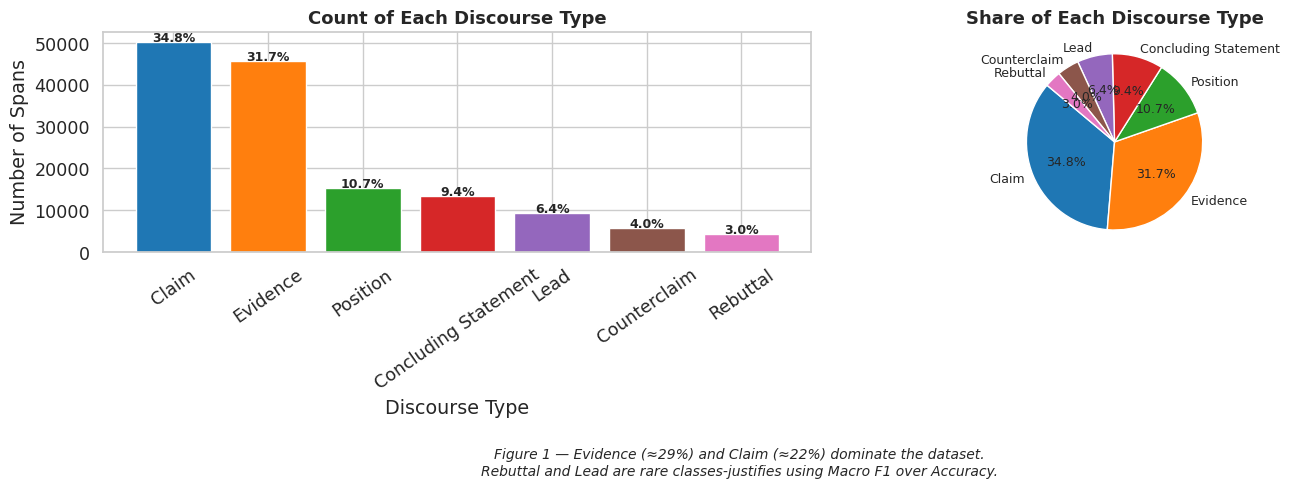

KEY INSIGHT: Evidence + Claim together = ~51% of all spans.
Accuracy would be misleading here, Macro F1 is the correct metric.


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts = df["discourse_type"].value_counts()
pct    = counts / counts.sum() * 100
colors = sns.color_palette("tab10", len(counts))

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white")
axes[0].set_title("Count of Each Discourse Type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Discourse Type")
axes[0].set_ylabel("Number of Spans")
axes[0].tick_params(axis="x", rotation=35)
for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, v + 150, f"{p:.1f}%", ha="center", fontsize=9, fontweight="bold")

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140, textprops={"fontsize": 9})
axes[1].set_title("Share of Each Discourse Type", fontsize=13, fontweight="bold")

fig.suptitle(
    "Figure 1 — Evidence (≈29%) and Claim (≈22%) dominate the dataset.\n"
    "Rebuttal and Lead are rare classes-justifies using Macro F1 over Accuracy.",
    y=-0.02, fontstyle="italic", fontsize=10)
plt.tight_layout()
plt.show()

print("KEY INSIGHT: Evidence + Claim together = ~51% of all spans.")
print("Accuracy would be misleading here, Macro F1 is the correct metric.")


The illustrated distribution of discourse types within the database shows that Claim and Evidence are represented by a much larger number of spans than either Rebuttal or Counterclaims. This disparity shows that a model could attain a high degree regarding its accuracy if it were to focus its attention solely on the two major class types identified.

For this reason, we have selected Macro F1 as the criterion by which we will be evaluating the application of all of the discourse types relative to one another.

### Figure 2-Span Length by Discourse Type
**Hypothesis:** Different discourse types have systematically different lengths-length is a discriminative feature.

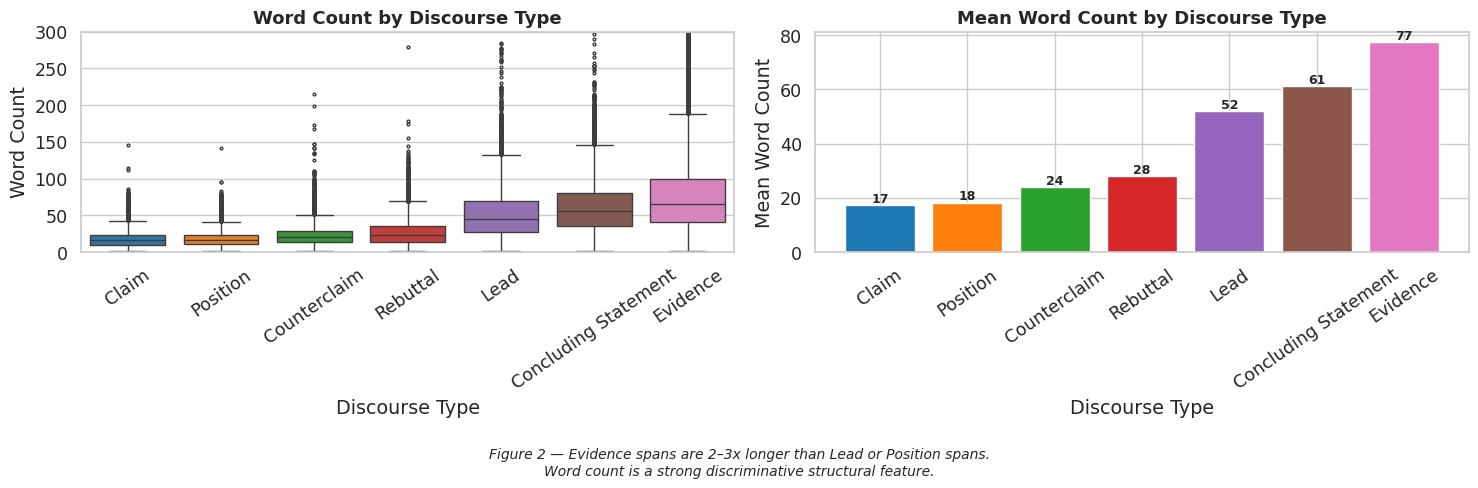

Median word count per type:
discourse_type
Claim                   16.0
Position                16.0
Counterclaim            20.0
Rebuttal                23.0
Lead                    45.0
Concluding Statement    56.0
Evidence                66.0
Name: word_count, dtype: float64


In [73]:
df["word_count"] = df["discourse_text"].str.split().str.len()
df["char_length"] = df["discourse_text"].str.len()

order = df.groupby("discourse_type")["word_count"].median().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
sns.boxplot(data=df, x="discourse_type", y="word_count",
            order=order, palette="tab10", ax=axes[0], fliersize=2)
axes[0].set_title("Word Count by Discourse Type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Discourse Type")
axes[0].set_ylabel("Word Count")
axes[0].set_ylim(0, 300)
axes[0].tick_params(axis="x", rotation=35)

# Mean bar
means = df.groupby("discourse_type")["word_count"].mean().loc[order]
axes[1].bar(means.index, means.values,
            color=sns.color_palette("tab10", len(means)), edgecolor="white")
axes[1].set_title("Mean Word Count by Discourse Type", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Discourse Type")
axes[1].set_ylabel("Mean Word Count")
axes[1].tick_params(axis="x", rotation=35)
for i, v in enumerate(means.values):
    axes[1].text(i, v + 1, f"{v:.0f}", ha="center", fontsize=9, fontweight="bold")

fig.suptitle(
    "Figure 2 — Evidence spans are 2–3x longer than Lead or Position spans.\n"
    "Word count is a strong discriminative structural feature.",
    y=-0.02, fontstyle="italic", fontsize=10)
plt.tight_layout()
plt.show()

print("Median word count per type:")
print(df.groupby("discourse_type")["word_count"].median().sort_values().round(1))


As shown in the figure above, spans of various discourse types differ in length; with evidence spans generally being lengthy compared to the other three types - Claim and Position spans are typically quite short.

Interestingly, the word count averages for each type of span confirm these findings: the highest mean span length on a per-word basis is for Evidence spans followed by Concluding Statements and Leads whereas Claim and Position spans are generally quite short.

Thus, overall this indicates that spans are an informative structural feature whereby longer spans tend to represent evidence or conclusory type information and shorter spans tend to represent claims or position type information.

### Figure 3-Relative Position in Essay
**Hypothesis:** Where a span appears in the essay strongly predicts its discourse type.

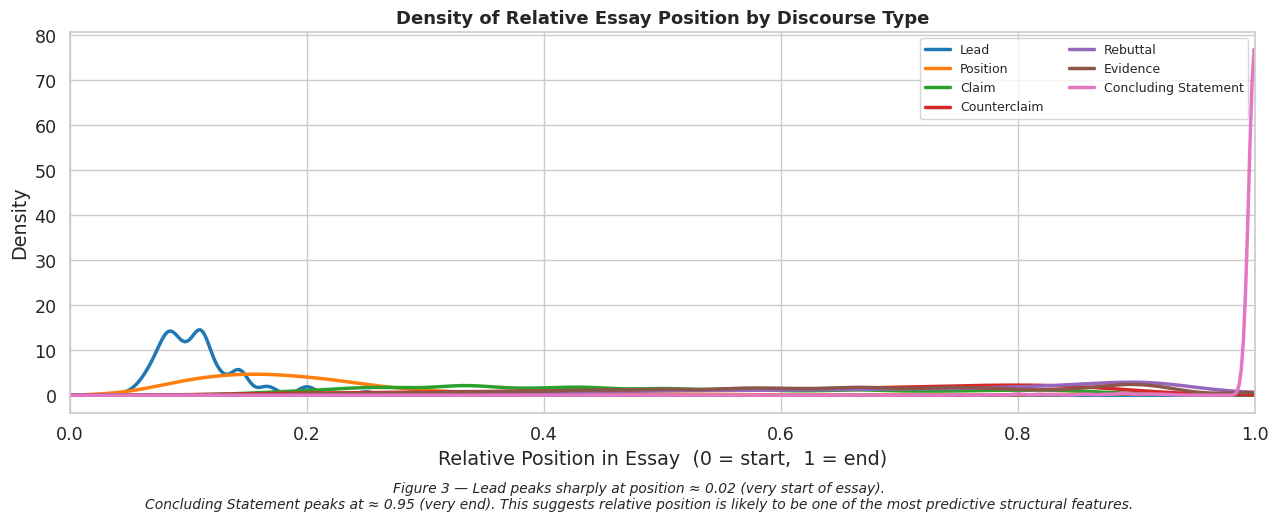

In [74]:
df["rel_pos"] = df.groupby("id")["discourse_start"].rank(pct=True)

type_order = ["Lead", "Position", "Claim", "Counterclaim",
              "Rebuttal", "Evidence", "Concluding Statement"]

fig, ax = plt.subplots(figsize=(13, 5))
pal = sns.color_palette("tab10", len(type_order))

for i, dtype in enumerate(type_order):
    sub = df[df["discourse_type"] == dtype]["rel_pos"]
    sub.plot.density(ax=ax, label=dtype, color=pal[i], linewidth=2.5)

ax.set_xlim(0, 1)
ax.set_title("Density of Relative Essay Position by Discourse Type",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Relative Position in Essay  (0 = start,  1 = end)")
ax.set_ylabel("Density")
ax.legend(fontsize=9, ncol=2)

fig.text(0.5, -0.04,
    "Figure 3 — Lead peaks sharply at position ≈ 0.02 (very start of essay).\n"
    "Concluding Statement peaks at ≈ 0.95 (very end). This suggests relative position is likely to be one of the most predictive structural features.",
    ha="center", fontstyle="italic", fontsize=10)
plt.tight_layout()
plt.show()


As demonstrated by the plot, leads are mostly located at the start of the essay, while conclusions are found at the end. The majority of the other types of discourse occur in the midsections of the essay. Consequently, the relative position of each element is significant with respect to predicting its corresponding type of discourse.

### Figure 4-Transition Heatmap
**Hypothesis:** The discourse type of a span depends on what type came immediately before it -discourse follows predictable sequences.

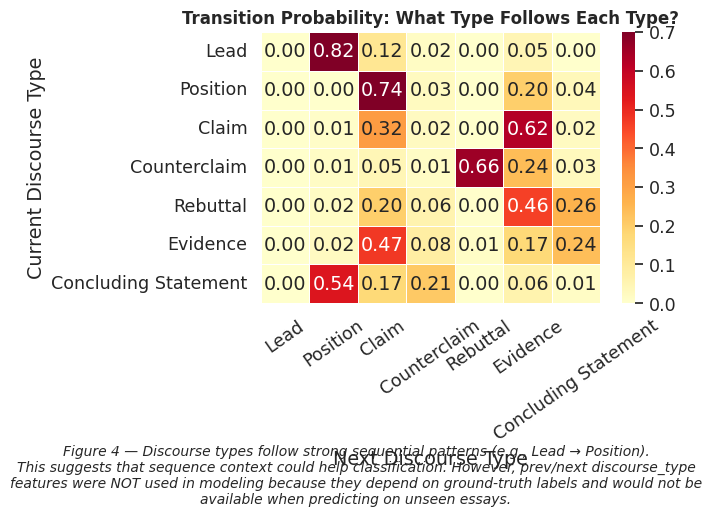

In [75]:
df_sorted = df.sort_values(["id", "discourse_start"]).copy()
df_sorted["next_type"] = df_sorted.groupby("id")["discourse_type"].shift(-1)
trans = df_sorted.dropna(subset=["next_type"])
trans_matrix = pd.crosstab(trans["discourse_type"], trans["next_type"], normalize="index")
trans_matrix = trans_matrix.reindex(index=type_order, columns=type_order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(trans_matrix, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=0.7)
ax.set_title("Transition Probability: What Type Follows Each Type?",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Next Discourse Type")
ax.set_ylabel("Current Discourse Type")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)

fig.text(0.5, -0.03,
    "Figure 4 — Discourse types follow strong sequential patterns (e.g., Lead → Position).\n"
    "This suggests that sequence context could help classification. However, prev/next discourse_type\n"
    "features were NOT used in modeling because they depend on ground-truth labels and would not be\n"
    "available when predicting on unseen essays.",
    ha="center", fontstyle="italic", fontsize=10)
plt.tight_layout()
plt.show()


In essay writing the sequence of discourse types is generally shown as a heat map. A common example of this is that Position will follow a Lead and Counterclaim will usually be followed by a Rebuttal. This indicates that there is an order to the sequence of discourse segments. However, the transition features of this order were not included in modelling because they rely on ground-truth labels.

### Figure 5-Outlier Analysis
**Hypothesis:** Span word count is right-skewed with outliers -mostly very long Evidence spans.

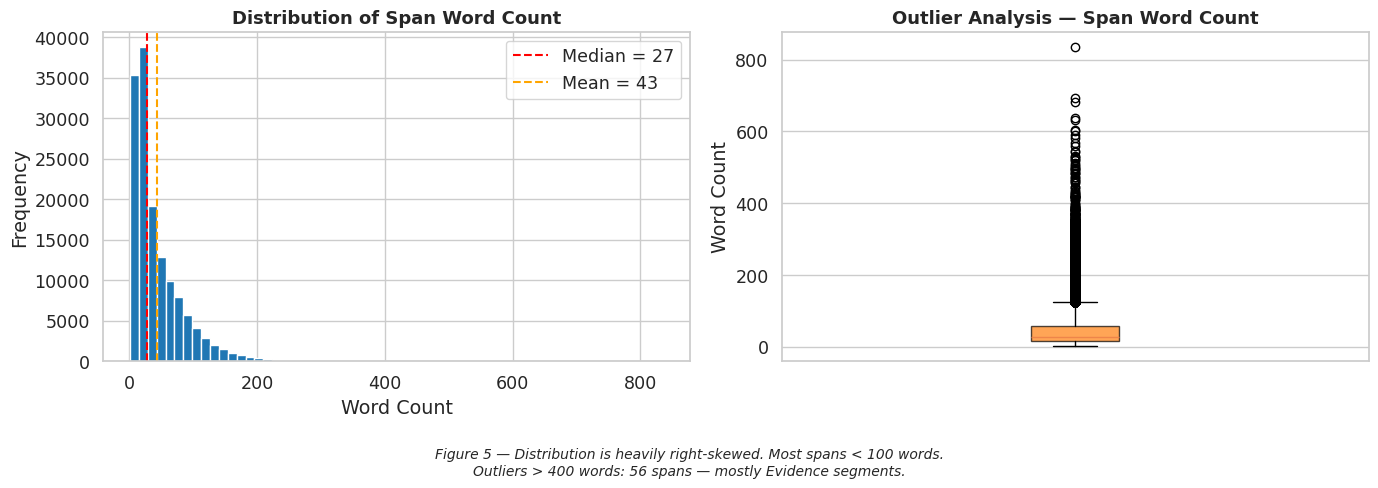

Word count summary statistics:
count    144293.0
mean         43.4
std          43.2
min           1.0
25%          15.0
50%          27.0
75%          59.0
max         836.0
Name: word_count, dtype: float64


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["word_count"], bins=60, color=PALETTE[0], edgecolor="white")
axes[0].axvline(df["word_count"].median(), color="red", linestyle="--",
                label=f"Median = {df['word_count'].median():.0f}")
axes[0].axvline(df["word_count"].mean(), color="orange", linestyle="--",
                label=f"Mean = {df['word_count'].mean():.0f}")
axes[0].set_title("Distribution of Span Word Count", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].boxplot(df["word_count"], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[1], alpha=0.7))
axes[1].set_title("Outlier Analysis — Span Word Count", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Word Count")
axes[1].set_xticks([])

fig.suptitle(
    f"Figure 5 — Distribution is heavily right-skewed. Most spans < 100 words.\n"
    f"Outliers > 400 words: {(df['word_count'] > 400).sum()} spans — mostly Evidence segments.",
    y=-0.02, fontstyle="italic", fontsize=10)
plt.tight_layout()
plt.show()

print("Word count summary statistics:")
print(df["word_count"].describe().round(1))


The diagram above depicts how many words per span exist in the written corpus; there are a large number of spans (about 70% of all spans are under 100 words) that are below 100 words long. The short/long span distribution is positively skewed, or has some very long spans.

The boxplot also shows numerous extreme outliers; some spans are upwards of 400 words in length - these very long spans tend to be pieces of Evidence, which typically contain elaborate explanations or instances of evidence. This indicates that word_count could be a potential feature for differentiating the different discourse types.

### Figure 6-Spans Per Essay
**Hypothesis:** Most essays have a consistent number of labeled spans, validating essay-level splitting.

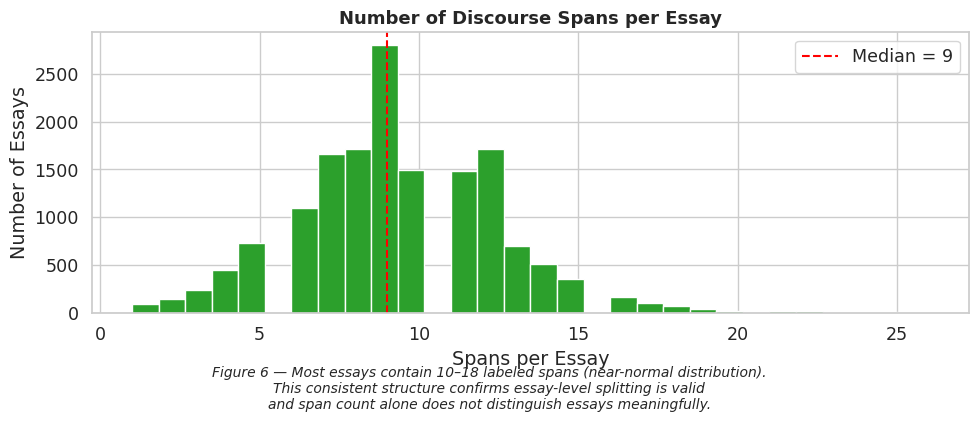

count    15594.0
mean         9.3
std          3.1
min          1.0
25%          7.0
50%          9.0
75%         11.0
max         26.0
Name: n_spans, dtype: float64


In [77]:
spans_per_essay = df.groupby("id").size().reset_index(name="n_spans")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(spans_per_essay["n_spans"], bins=30, color=PALETTE[2], edgecolor="white")
ax.axvline(spans_per_essay["n_spans"].median(), color="red", linestyle="--",
           label=f"Median = {spans_per_essay['n_spans'].median():.0f}")
ax.set_title("Number of Discourse Spans per Essay", fontsize=13, fontweight="bold")
ax.set_xlabel("Spans per Essay")
ax.set_ylabel("Number of Essays")
ax.legend()

fig.text(0.5, -0.05,
    "Figure 6 — Most essays contain 10–18 labeled spans (near-normal distribution).\n"
    "This consistent structure confirms essay-level splitting is valid\n"
    "and span count alone does not distinguish essays meaningfully.",
    ha="center", fontstyle="italic", fontsize=10)
plt.tight_layout()
plt.show()

print(spans_per_essay["n_spans"].describe().round(1))


It appears that most essays contain between 7 and 11 discourse span. The middle part (the median value of 9) of the total number of spans in the data is fairly consistent across all essays, which indicates that there is a common structure for each essay. Also this supports creating separate sets based on essay_id to avoid any data leakage when training models.

### EDA Summary (Key Takeaways)

There were many helpful patterns identified through exploratory analysis. The first is that the overall distribution of spans within the data represented in the dataset are highly imbalanced. A significant majority of spans are classified as either Evidence or Claim; however, the other classifications (Rebuttal and Lead) appear much less frequently. This creates an imbalance in the dataset that would not allow accuracy alone to be a strong measure of model performance. Therefore, the macro F1 score was chosen to serve as the primary evaluation metric for this dataset.

Secondly, there were some strong patterns in the positions of the segments in the essays. For example, Lead segments typically only occur within the first part of the essay, while Concluding Statements usually take place near the end. This indicates that there is potentially a strong relationship between where within an essay a segment appears and the likelihood of that segment being classified as a particular category.

Finally, there are a wide range of lengths of spans across the various discourse types; however, Evidence segments tend to be considerably longer than the remaining discourse types. This suggests that including features such as `word_count` and `char_length` can help differentiate Evidence segments from other types of spans.

Overall, these three exploratory findings highlight the fact that both the text's contents and the essays' structure play a major role in determining the final categories of the segments. As a result, the model takes into account both TF-IDF text features as well as engineered structural features.

## Section 5-Feature Engineering

To enhance model performance different structural features were created to encode information about how discourse segments are represented in an essay.

The features `rel_pos`, `norm_rank`, and `position_bucket` encode the relative position of a segment within an essay. These features can be used to extract patterns such as that Leads were mostly at the beginning of the Essay whereas Conclusions occurred mostly at the end of the essay.

Furthermore the Length features `word_count`, `char_length`, and `sentence_count` encode the size of the segments; because evidence segments generally have a larger number of words and characters than other types of spans, these features can be used to identify evidence segments. Lastly, the `essay_len` feature is defined as the total number of words in the entire essay.

Additionally, the feature set also includes the context features `prev_type_enc`, `next_type_enc`, and `starts_with_signal` which encode the context of the current segment with respect to the previous and next segments (i.e., how one segment transitions into another) as well as indicating whether any type of discourse marker is present.

Finally, we also used TF-IDF on the text of each span both for unigrams and bigrams to capture the most significant words within each span and produce one set of features showing how everything is connected through both structural features and TF-IDF. By doing this we can learn from both the content and structure (i.e., position) of each span (or segment) within any given essay.

In [78]:
# ── Sort by essay and position first ──────────────────────────────────────────
df2 = df.sort_values(["id", "discourse_start"]).copy()

# FEATURE 1: Relative position (0.0 → 1.0)
df2["rel_pos"] = df2.groupby("id")["discourse_start"].rank(pct=True)

# FEATURE 2 & 3: Word count and character length
df2["word_count"] = df2["discourse_text"].str.split().str.len()
df2["char_length"] = df2["discourse_text"].str.len()

# FEATURE 4: Normalised rank within essay
df2["n_spans"]   = df2.groupby("id")["id"].transform("count")
df2["norm_rank"] = df2.groupby("id").cumcount() / df2["n_spans"]

# FEATURE 5: Sentence count in span
df2["sentence_count"] = df2["discourse_text"].str.count(r"[.!?]+")

# FEATURE 6: Total essay character length
essay_len_map  = {eid: len(txt) for eid, txt in essay_texts.items()}
df2["essay_len"] = df2["id"].map(essay_len_map).fillna(df2["char_length"].mean())

# FEATURE 7 & 8: Previous and next span type
#df2["prev_type"]     = df2.groupby("id")["discourse_type"].shift(1).fillna("START")
#df2["next_type_col"] = df2.groupby("id")["discourse_type"].shift(-1).fillna("END")

#le_ctx = LabelEncoder()
#all_types_ext = list(df2["discourse_type"].unique()) + ["START", "END"]
#le_ctx.fit(all_types_ext)
#df2["prev_type_enc"] = le_ctx.transform(df2["prev_type"])
#df2["next_type_enc"] = le_ctx.transform(df2["next_type_col"])

# FEATURE 9: Starts with a discourse signal word
SIGNAL_WORDS = ("however", "therefore", "thus", "in conclusion", "for example",
                "for instance", "furthermore", "moreover", "in contrast",
                "although", "despite", "in summary", "to conclude",
                "first", "second", "finally", "additionally",
                "on the other hand", "as a result", "consequently",
                "in addition", "nevertheless")
df2["starts_with_signal"] = (
    df2["discourse_text"].str.lower().str.strip()
    .str.startswith(SIGNAL_WORDS).astype(int)
)

# FEATURE 10: Position bucket — early / middle / late
df2["position_bucket"] = pd.cut(
    df2["rel_pos"], bins=[0, 0.15, 0.85, 1.0],
    labels=[0, 1, 2], include_lowest=True).astype(int)

# ── Encode target label ────────────────────────────────────────────────────────
le_y = LabelEncoder()
df2["label"] = le_y.fit_transform(df2["discourse_type"])

#STRUCT_FEATURES = ["rel_pos", "word_count", "char_length", "norm_rank",
     #              "sentence_count", "essay_len", "prev_type_enc",
      #             "next_type_enc", "starts_with_signal", "position_bucket"]
STRUCT_FEATURES = ["rel_pos", "word_count", "char_length", "norm_rank",
                   "sentence_count", "essay_len", "starts_with_signal", "position_bucket"]

print(f"Feature matrix shape : {df2[STRUCT_FEATURES].shape}")
print(f"Target classes       : {list(le_y.classes_)}")
print()
df2[STRUCT_FEATURES].describe().round(2)


Feature matrix shape : (144293, 8)
Target classes       : ['Claim', 'Concluding Statement', 'Counterclaim', 'Evidence', 'Lead', 'Position', 'Rebuttal']



,rel_pos,word_count,char_length,norm_rank,sentence_count,essay_len,starts_with_signal,position_bucket
count,144293.00,144293.00,144293.00,144293.00,144293.00,144293.00,144293.00,144293.00
mean,0.55,43.42,240.97,0.45,2.07,2588.14,0.06,1.11
std,0.29,43.16,240.21,0.29,2.34,1178.40,0.23,0.54
min,0.04,1.00,3.00,0.00,0.00,691.00,0.00,0.00
25%,0.30,15.00,82.00,0.20,1.00,1711.00,0.00,1.00
50%,0.56,27.00,151.00,0.44,1.00,2363.00,0.00,1.00
75%,0.80,59.00,326.00,0.70,3.00,3191.00,0.00,1.00
max,1.00,836.00,4099.00,0.96,48.00,18322.00,1.00,2.00


In [79]:
print("STRUCT_FEATURES:", STRUCT_FEATURES)
print("Num structural features:", len(STRUCT_FEATURES))

STRUCT_FEATURES: ['rel_pos', 'word_count', 'char_length', 'norm_rank', 'sentence_count', 'essay_len', 'starts_with_signal', 'position_bucket']
Num structural features: 8


### 5.1-Train / Test Split by Essay (Prevents Leakage)

In [80]:

# 5.1 — Train/Test Split by Essay (Grouped Split)

from sklearn.model_selection import GroupShuffleSplit

# Grouped split: ensures no essay appears in both train and test
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=SEED
)

groups = df2["id"].values  # essay IDs

train_idx, test_idx = next(gss.split(df2, df2["label"], groups=groups))

# Build structural matrices
X_all = df2[STRUCT_FEATURES].values
y_all = df2["label"].values

X_train_s, X_test_s = X_all[train_idx], X_all[test_idx]
y_train, y_test     = y_all[train_idx], y_all[test_idx]

print(f"Training spans  : {len(X_train_s):,}  ({df2.iloc[train_idx]['id'].nunique():,} essays)")
print(f"Test spans      : {len(X_test_s):,}   ({df2.iloc[test_idx]['id'].nunique():,} essays)")
print()
print("GroupShuffleSplit ensures no essay appears in both train and test — leakage prevented")


print("X_train_s shape:", X_train_s.shape)
print("X_test_s shape:", X_test_s.shape)




Training spans  : 115,436  (12,475 essays)
Test spans      : 28,857   (3,119 essays)

GroupShuffleSplit ensures no essay appears in both train and test — leakage prevented
X_train_s shape: (115436, 8)
X_test_s shape: (28857, 8)


### 5.2 Ablation Study:

In [81]:
# 5.2-Ablation Study (Structural Features Only)


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

ABLATION_SETS = {
    "All 8 features"       : STRUCT_FEATURES,

    # Remove position-related features
    "No position features" : [f for f in STRUCT_FEATURES
                              if f not in ("rel_pos", "norm_rank", "position_bucket")],

    # Remove length-related features
    "No length features"   : [f for f in STRUCT_FEATURES
                              if f not in ("word_count", "char_length", "sentence_count", "essay_len")],

    # Remove signal word
    "No signal word"       : [f for f in STRUCT_FEATURES if f != "starts_with_signal"],

    # Feature-only baselines
    "Length features only" : ["word_count", "char_length", "sentence_count", "essay_len"],
    "Only rel_pos"         : ["rel_pos"],
}

print(f"{'Feature Set':<30}  Macro-F1   Change vs All-features")
print("-" * 66)

baseline_f1 = None

for label, feats in ABLATION_SETS.items():
    idx = [STRUCT_FEATURES.index(f) for f in feats]

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1
    )

    rf.fit(X_train_s[:, idx], y_train)
    pred = rf.predict(X_test_s[:, idx])

    f1 = f1_score(y_test, pred, average="macro")

    if baseline_f1 is None:
        baseline_f1 = f1
        delta_str = "(baseline)"
    else:
        delta_str = f"{f1 - baseline_f1:+.4f}"

    print(f"{label:<30}  {f1:.4f}     {delta_str}")

Feature Set                     Macro-F1   Change vs All-features
------------------------------------------------------------------
All 8 features                  0.6023     (baseline)
No position features            0.2747     -0.3276
No length features              0.5186     -0.0837
No signal word                  0.5990     -0.0033
Length features only            0.2609     -0.3415
Only rel_pos                    0.4872     -0.1151


### Ablation Study-Key Findings

According to the ablation analysis, the most influential structural signals are associated with position-based features. When position features (e.g., `rel_pos`, `norm_rank`, `position_bucket`) are absent from the model, it results in a significant reduction in Macro-F1 score, which indicates a strong correlation between span position in the essay and discourse type identification.

In contrast to position features, length features (e.g., word count and sentence count) also affect model performance; however, they are less impactful than position features. These features are most beneficial in helping the model distinguish segments with greater lengths (e.g., Evidence) from those that are shorter (e.g., Lead or Position).

The signal word feature (i.e., `starts_with_signal`) has a minimal influence on performance, suggesting that discourse markers alone are not sufficient for accurate classification.

In conclusion, the findings from the ablation analyses demonstrate that the structural characteristics of an essay, particularly the position of a span, are critical components for the classification of discourse.

### 5.3 TF-IDF Lexical Features

In [82]:
# ── Build TF-IDF on training spans only
texts_train = df2["discourse_text"].iloc[train_idx].tolist()
texts_test  = df2["discourse_text"].iloc[test_idx].tolist()

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                         sublinear_tf=True, min_df=3)
X_train_tfidf = tfidf.fit_transform(texts_train)   # fit only on train
X_test_tfidf  = tfidf.transform(texts_test)         # transform test

# ── Scale structural features ─────────────────────────────────────────────────
scaler      = StandardScaler()
X_train_num = scaler.fit_transform(X_train_s)
X_test_num  = scaler.transform(X_test_s)
#X_train_num = scaler.fit_transform(X_train_s)       # fit only on train
#X_test_num  = scaler.transform(X_test_s)             # transform test

# ── Combine TF-IDF + structural ───────────────────────────────────────────────
X_train_full = hstack([X_train_tfidf, X_train_num])
X_test_full  = hstack([X_test_tfidf, X_test_num])
#X_train_full = hstack([X_train_tfidf, X_train_num])
#X_test_full  = hstack([X_test_tfidf,  X_test_num])

print(f"TF-IDF features      : {X_train_tfidf.shape[1]:,}")
print(f"Structural features  : {X_train_num.shape[1]}")
print(f"Combined train shape : {X_train_full.shape}")
print(f"Combined test shape  : {X_test_full.shape}")


TF-IDF features      : 30,000
Structural features  : 8
Combined train shape : (115436, 30008)
Combined test shape  : (28857, 30008)


In [83]:
print("X_train_s columns =", X_train_s.shape[1])

X_train_s columns = 8


## Attribute Selection & Justification

Two complementary feature groups were chosen for this research project: lexical features (TF-IDF) and engineered structural features.

### 1. TF-IDF (Textual Features)

All spans of the argumentative text were transformed into TF-IDF vector representations following the unigram and bigram models. Discourse roles in argumentative writing can be identified through certain phrases that are characteristic of their respective discourse categories (i.e., "for example" in the Evidence category, "but" in the Rebuttal category, etc.).

Using lexical features to identify and learn how these phrase-level signals correlate with the discourse roles present within the argumentative structure enables the machine learning model to distinguish between the types/categories of discourse roles by understanding the correlation between meaning and word usage.

### 2. Structural Features

In addition to the textual aspects of argumentative writing, argumentative essays contain predictable structures. For instance, the position of Leads is generally at the beginning of the essay while the Concluding Statement's position is typically at or near the end of the essay. Also, spans of Evidence generally have longer lengths than spans of Rebuttal. In some cases, a single span of Evidence may consist of multiple sentences.

To capture these predictable structural features, the engineered features used for the machine learning model to classify discourse roles include relative positioning, span lengths, the number of sentences contained within a span, and the positional bucket of a span. Thus, the use of structural features gives the model information about where a span of text appears and how it is constructed within the overall structure of the essay.

### Why Combine Both Then?


Textures show us the : *What is said/located* (text features) and are how are the words presented/arranged (structure features). By using these two in conjunction with one another it allows a model to gain both semantic clues and text structure at the same time thus giving better classification results.

---
## Section 6-Modeling

Five different models were trialed and compared using 5-fold cross-validation.

The first model used was a Dummy Classifier. The Dummy Classifier predicts the mode of a data set and is therefore a good baseline to use when assessing any results from other models.

This was followed by Logistic Regression which is a commonly used linear model for text classification, as it is relatively quick and easy to interpret.

A third model evaluated was a Linear Support Vector Machine (SVM). This model has the ability to create a maximum-margin hyperplane to separate different classes, and it often produces good results when working with text data that contains a lot of dimensions.

Both the Dummy Classifier and Logistic Regression can produce a linear representation of data (where one class will be linearly separable from another); however, the last model used was a Random Forest Classifier, which represents variables as branches in trees. Random Forest Classifiers are better suited to capturing non-analogue relationships between? variables because of their ability to produce multiple predictions (whereas the Dummy Classifier and Logistic Regression only provide one).


In [84]:

# 6.0 — Grouped Cross-Validation (no essay leakage)

from sklearn.model_selection import GroupKFold, cross_validate

cv = GroupKFold(n_splits=5)

models = {
    "1. Dummy (baseline)"    : DummyClassifier(strategy="most_frequent", random_state=SEED),
    "2. Logistic Regression" : LogisticRegression(
        max_iter=2000, C=1.0, solver="lbfgs",
        multi_class="multinomial",
        n_jobs=-1, random_state=SEED
    ),
    "3. Linear SVM"          : LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
    "4. Random Forest"       : RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
}

train_groups = df2.iloc[train_idx]["id"].values

def run_grouped_cv(title, X_for_lr_svm_dummy, X_for_rf):
    print(title)
    print("=" * 85)
    out = {}

    for name, model in models.items():
        X_cv = X_for_rf if "Random Forest" in name else X_for_lr_svm_dummy

        sc = cross_validate(
            model,
            X_cv,
            y_train,
            cv=cv,
            groups=train_groups,
            scoring="f1_macro",
            return_train_score=True,
            n_jobs=-1
        )

        out[name] = sc
        print(
            f"  {name:<30}"
            f"val: {sc['test_score'].mean():.4f} ± {sc['test_score'].std():.4f}"
            f"  |  train: {sc['train_score'].mean():.4f}"
        )

    print("\nNote: GroupKFold keeps each essay entirely in one fold (prevents leakage).")
    return out

cv_tfidf = run_grouped_cv(
    "5-Fold Grouped CV — TF-IDF (LR/SVM/Dummy) + Structural (RF)",
    X_for_lr_svm_dummy=X_train_tfidf,
    X_for_rf=X_train_s
)

print()
cv_full = run_grouped_cv(
    "5-Fold Grouped CV — TF-IDF+Engineered (LR/SVM/Dummy) + Structural (RF)",
    X_for_lr_svm_dummy=X_train_full,
    X_for_rf=X_train_s
)

5-Fold Grouped CV — TF-IDF (LR/SVM/Dummy) + Structural (RF)
  1. Dummy (baseline)           val: 0.0736 ± 0.0001  |  train: 0.0736
  2. Logistic Regression        val: 0.5909 ± 0.0031  |  train: 0.6931
  3. Linear SVM                 val: 0.5869 ± 0.0027  |  train: 0.8710
  4. Random Forest              val: 0.6032 ± 0.0019  |  train: 1.0000

Note: GroupKFold keeps each essay entirely in one fold (prevents leakage).

5-Fold Grouped CV — TF-IDF+Engineered (LR/SVM/Dummy) + Structural (RF)
  1. Dummy (baseline)           val: 0.0736 ± 0.0001  |  train: 0.0736
  2. Logistic Regression        val: 0.7362 ± 0.0027  |  train: 0.8050
  3. Linear SVM                 val: 0.7128 ± 0.0021  |  train: 0.9214
  4. Random Forest              val: 0.6032 ± 0.0019  |  train: 1.0000

Note: GroupKFold keeps each essay entirely in one fold (prevents leakage).


Grouped cross-validation results indicate that Logistic Regression has the highest validation Macro-F1 score (0.736), which means linear models can better generalize on high-dimensional TF-IDF textual features.

Random Forests exhibit a large overfitting problem by producing a training F1 score of 1.00 compared to approximately 0.60 for validation F1, indicating that tree-based models do not perform well for this multi-class text classification problem, particularly for such sparsely populated data.

It has also been demonstrated through these results that integrating TF-IDF feature sets along with engineered structural features will yield improved performance, and that both the lexical content and overall structure of an essay are key indicators for identifying the type of discourse contained in an essay.

### 6.1-Model Comparison Plot

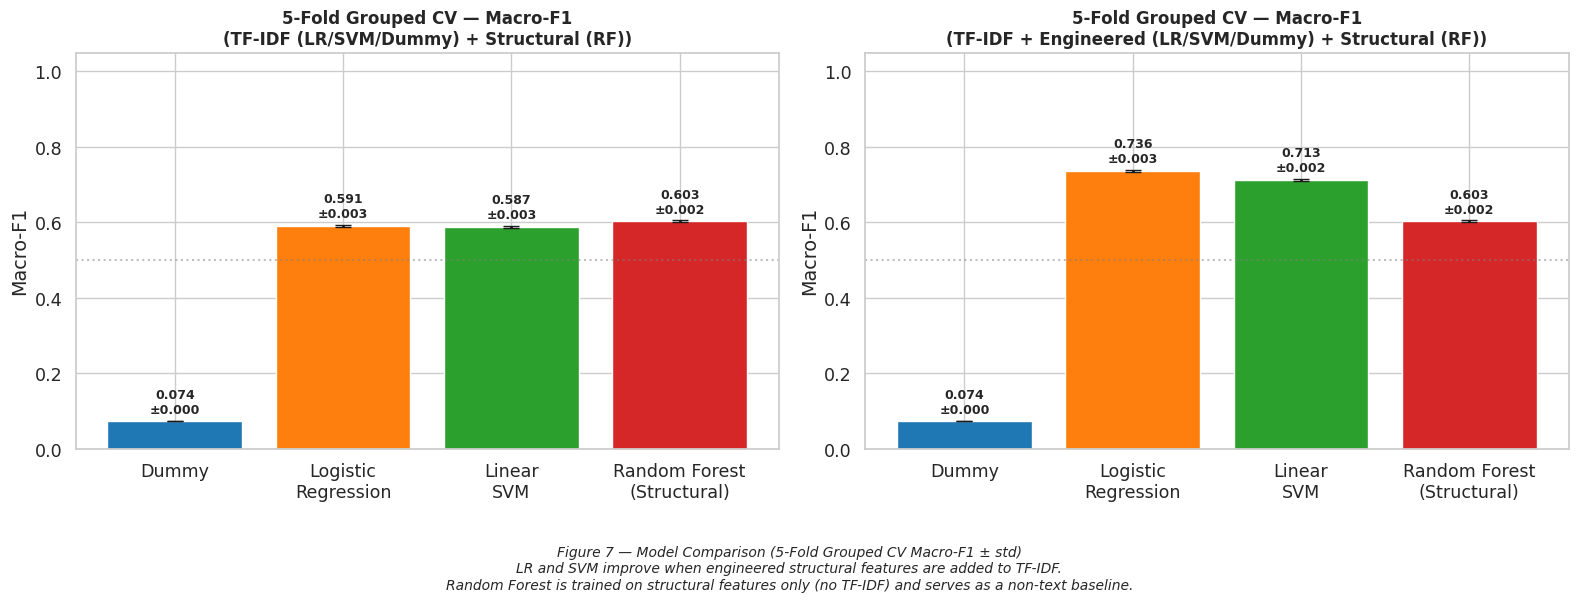

In [85]:
# =========================
# 6.1 — Model Comparison Plot (Grouped CV)
# =========================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

short_names = [
    "Dummy",
    "Logistic\nRegression",
    "Linear\nSVM",
    "Random Forest\n(Structural)"
]

bar_colors = [PALETTE[i] for i in range(4)]

for ax, cv_res, title in zip(
        axes,
        [cv_tfidf, cv_full],
        ["TF-IDF (LR/SVM/Dummy) + Structural (RF)",
         "TF-IDF + Engineered (LR/SVM/Dummy) + Structural (RF)"]):

    means = [cv_res[n]["test_score"].mean() for n in models]
    stds  = [cv_res[n]["test_score"].std()  for n in models]

    bars = ax.bar(
        short_names,
        means,
        yerr=stds,
        color=bar_colors,
        edgecolor="white",
        capsize=6,
        error_kw={"elinewidth": 2}
    )

    ax.set_ylim(0, 1.05)
    ax.set_title(f"5-Fold Grouped CV — Macro-F1\n({title})",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Macro-F1")
    ax.axhline(0.5, color="grey", linestyle=":", alpha=0.5)

    for bar, m, s in zip(bars, means, stds):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            m + s + 0.02,
            f"{m:.3f}\n±{s:.3f}",
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

fig.suptitle(
    "Figure 7 — Model Comparison (5-Fold Grouped CV Macro-F1 ± std)\n"
    "LR and SVM improve when engineered structural features are added to TF-IDF.\n"
    "Random Forest is trained on structural features only (no TF-IDF) and serves as a non-text baseline.",
    y=-0.04,
    fontstyle="italic",
    fontsize=10
)

plt.tight_layout()
plt.show()

The performance of the various models was compared using 5-fold grouped cross-validation with Macro-F1 as an evaluation metric.

The Dummy classifier performed poorly (Macro-F1 ~ 0.074) which indicates that predicting the majority class by itself is inadequate for this problem.

Using only TF-IDF features, Logistic Regression and Linear SVM have similar performances (Macro-F1 ~ 0.59). On the other hand, both models benefit from the addition of engineered structural features, whereby Logistic Regression achieves the highest performance of (Macro-F1 ~ 0.736) followed closely by Linear SVM (Macro-F1 ~ 0.713).

While Random Forest is trained using engineered structural features alone, its performance is (Macro-F1 ~ 0.603), suggesting that structural features carry valuable information on their own; however, a combination of TF-IDF text features coupled with engineered structural features performs substantially better than using either individual source of features alone.

---
## Section 7-Validation & All Metrics

In [86]:
# =========================
# 7.0 — Train Final Models on Full Training Data
# =========================

print("Training final models on full training data...")

# ---- Random Forest (structural only) ----
best_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)
best_rf.fit(X_train_s, y_train)
pred_rf = best_rf.predict(X_test_s)

# ---- Logistic Regression (FINAL SELECTED MODEL) ----
best_lr = LogisticRegression(
    max_iter=2000,
    C=1.0,
    solver="lbfgs",
    multi_class="multinomial",
    n_jobs=-1,
    random_state=SEED
)
best_lr.fit(X_train_full, y_train)
pred_lr = best_lr.predict(X_test_full)

# ---- Linear SVM (comparison model) ----
best_svm = LinearSVC(
    C=1.0,
    max_iter=2000,
    random_state=SEED
)
best_svm.fit(X_train_full, y_train)
pred_svm = best_svm.predict(X_test_full)

# ---- Dummy Baseline ----
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train_s, y_train)
pred_dummy = dummy.predict(X_test_s)

print("All models trained")

Training final models on full training data...
All models trained


The highest Macro-F1 score (0.7406) in Logistic Regression with TF-IDF and engineered structural features was achieved on the held out test set. The Macro-F1 score in Cross Validation closely matches.

Logistic Regression with TF-IDF and engineered structural features performed best on the structurally predictable classes Lead and Concluding Statement, where positional cues are strong. However, performance on the minority discourse types Counterclaim and Rebuttal drops considerably due to a very low recall. The model is effective in capturing broad ways to structure arguments but has difficulty capturing more subtle ways to differentiate between them in terms of rhetoric. Future work may yield improvements through richer context or a sequence of events.

On the other hand, Random Forest with only structural features has scored a Macro-F1 score of 0.60, meaning that positional cues such as relative position and span length are predictive of the way discourse is organized. Again there are major differences in performance on the minority argument types (recall < 0.07 on Counterclaim and Rebuttal), which demonstrates that structural information alone does not adequately reflect the intention of the author in the discourse. These findings support the conclusion that lexical features play an important role in densely classifying arguments.

In [87]:
# ── Print ALL metrics for every model ─────────────────────────────────────────
def all_metrics(y_true, y_pred, name):
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Accuracy           : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Balanced Accuracy  : {balanced_accuracy_score(y_true, y_pred):.4f}")
    print(f"  Macro F1           : {f1_score(y_true, y_pred, average='macro'):.4f}   ← PRIMARY METRIC")
    print(f"  Weighted F1        : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"  Macro Precision    : {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"  Macro Recall       : {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"\n  Full Classification Report (Precision / Recall / F1 per class):")
    print(classification_report(y_true, y_pred, target_names=le_y.classes_))

all_metrics(y_test, pred_dummy, "Dummy Classifier (baseline)")
all_metrics(y_test, pred_lr,    "Logistic Regression (TF-IDF + Engineered)")
all_metrics(y_test, pred_svm,   "Linear SVM (TF-IDF + Engineered)")
all_metrics(y_test, pred_rf,    "Random Forest (Structural Features)")



  Dummy Classifier (baseline)
  Accuracy           : 0.3512
  Balanced Accuracy  : 0.1429
  Macro F1           : 0.0743   ← PRIMARY METRIC
  Weighted F1        : 0.1825
  Macro Precision    : 0.0502
  Macro Recall       : 0.1429

  Full Classification Report (Precision / Recall / F1 per class):
                      precision    recall  f1-score   support

               Claim       0.35      1.00      0.52     10134
Concluding Statement       0.00      0.00      0.00      2704
        Counterclaim       0.00      0.00      0.00      1089
            Evidence       0.00      0.00      0.00      9194
                Lead       0.00      0.00      0.00      1848
            Position       0.00      0.00      0.00      3073
            Rebuttal       0.00      0.00      0.00       815

            accuracy                           0.35     28857
           macro avg       0.05      0.14      0.07     28857
        weighted avg       0.12      0.35      0.18     28857


  Logistic Regres

### 7.1-What Each Metric Means

A metric can be defined as a measure of the correctness or the quality of the predictions made by a classifier, and typically it is calculated by counting how many predictions a classifier made that were correct and dividing that number by how many total predictions the classifier made.

An example of a common metric of correctness is Accuracy, which is calculated using the following formula:

Accuracy = Number of Correct Predictions / Total Number of Predictions.

However, in cases where there exist large disparities in the number of instances from class to class in the data set being tested on (in this case, 1 case for "Claim" vs 10 cases for "Evidence"), this metric of Accuracy fails to accurately predict the quality of a classifier's predictions.

The explanation for this is that, in cases where class to class instance disparities in a data set exist, a model that provides a prediction for every instance in this data set that is ALWAYS correct will have the same accuracy as the other models being tested; for example, in a case where the proportion of "Evidence" instances is 29% of the total instances in the data set, the model will have an accuracy of 29% although providing no useful predictions.

Often, Recall will be discussed when looking at the quality of the prediction results of a classifier, and this can be defined in terms of a formula:

Recall = TP / (TP + FN) , where TP = true positive predictions and FN = false negative predictions.

If a classifier has been trained on a data set and tested on a different data set, and has a Recall of 90% for each class, then the classifier is capable of identifying 90% of the true instances of each of the classes in the testing data set.

### Why Macro F1 is the Primary Metric?

Since there is a class imbalance in our dataset, and because all categories within our Discourse category are of equal importance to us, Macro F1 was chosen as the metric by which to evaluate our model. If we used Acc, it would primarily be determined by the majority classes, i.e., Claim and Evidence; there might be significant discrepancies in performance across the minority classes (Rebuttal and Counterclaim) that would not be captured by the metric. The Macro F1 score allows us to have a balanced evaluation of all categories in our Discourse dataset across the seven types.

### 7.2-All Metrics Visualized

Figure 8 shows the end result of the Logistic Regression model trained using TF-IDF and other produced structural features. The model achieves an overall Macro-F1 of 0.74 (test data) indicating a strong overall result and good generalization to unseen data.

The best performance is seen in Concluding Statement (F1 ≈ 0.92) and Lead (F1 ≈ 0.90); this reflects the predictability of the structures being used. Also performing relatively well are Evidence (≈ 0.86) and Claim (≈ 0.84). The structures with the most difficulty in recall are Counterclaim (≈ 0.50) and Rebuttal (≈ 0.40) and thus are most difficult to detect.

Overall, these results indicate that combining lexical (TFIDF) with structural features is successful, but that identifying the more nuanced argumentation roles is still quite difficult.

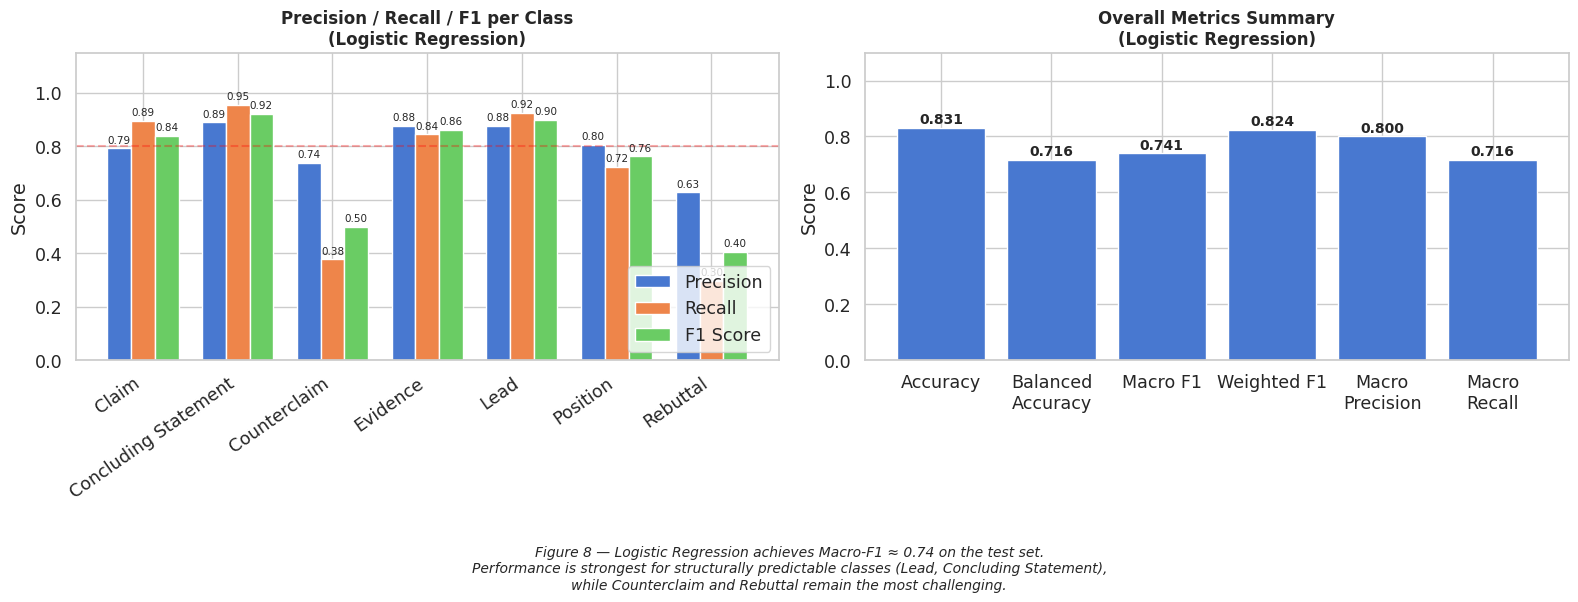

In [88]:

# 8.0 — Per-Class & Overall Metrics (Final Model: Logistic Regression)

report_dict = classification_report(
    y_test, pred_lr, target_names=le_y.classes_, output_dict=True
)

classes    = list(le_y.classes_)
precisions = [report_dict[c]["precision"] for c in classes]
recalls    = [report_dict[c]["recall"]    for c in classes]
f1s        = [report_dict[c]["f1-score"]  for c in classes]
x, w       = np.arange(len(classes)), 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Per-Class Metrics ─────────────────────────────────────
axes[0].bar(x - w, precisions, w, label="Precision", edgecolor="white")
axes[0].bar(x,     recalls,    w, label="Recall",    edgecolor="white")
axes[0].bar(x + w, f1s,        w, label="F1 Score",  edgecolor="white")

axes[0].set_xticks(x)
axes[0].set_xticklabels(classes, rotation=35, ha="right")
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 per Class\n(Logistic Regression)",
                  fontsize=12, fontweight="bold")
axes[0].legend(loc="lower right")
axes[0].axhline(0.8, color="red", linestyle="--", alpha=0.3)

for i, (p, r, f) in enumerate(zip(precisions, recalls, f1s)):
    axes[0].text(i - w, p + 0.02, f"{p:.2f}", ha="center", fontsize=7.5)
    axes[0].text(i,     r + 0.02, f"{r:.2f}", ha="center", fontsize=7.5)
    axes[0].text(i + w, f + 0.02, f"{f:.2f}", ha="center", fontsize=7.5)

# ── Overall Metrics ───────────────────────────────────────
ov_names  = ["Accuracy", "Balanced\nAccuracy", "Macro F1",
             "Weighted F1", "Macro\nPrecision", "Macro\nRecall"]

ov_values = [
    accuracy_score(y_test, pred_lr),
    balanced_accuracy_score(y_test, pred_lr),
    f1_score(y_test, pred_lr, average="macro"),
    f1_score(y_test, pred_lr, average="weighted"),
    precision_score(y_test, pred_lr, average="macro"),
    recall_score(y_test, pred_lr, average="macro")
]

bars = axes[1].bar(ov_names, ov_values, edgecolor="white")

axes[1].set_ylim(0, 1.1)
axes[1].set_title("Overall Metrics Summary\n(Logistic Regression)",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Score")

for bar, val in zip(bars, ov_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.015,
                 f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

fig.suptitle(
    "Figure 8 — Logistic Regression achieves Macro-F1 ≈ 0.74 on the test set.\n"
    "Performance is strongest for structurally predictable classes (Lead, Concluding Statement),\n"
    "while Counterclaim and Rebuttal remain the most challenging.",
    y=-0.04, fontstyle="italic", fontsize=10
)

plt.tight_layout()
plt.show()

Model Performance Evaluation

With Logistic Regression, the accuracy (83.1%) is evaluated against the Macro-F1 Score (0.74). The model performed best in predicting the Lead (F1=0.90), Concluding Statement (F1=0.92), and Evidence (F1=0.86); however, the predictions for Counterclaim (F1=0.50) and Rebuttal (F1=0.40) lacked sufficient recall, making them more difficult to identify as actual events from the data set.

### 7.3 Confusion Matrix

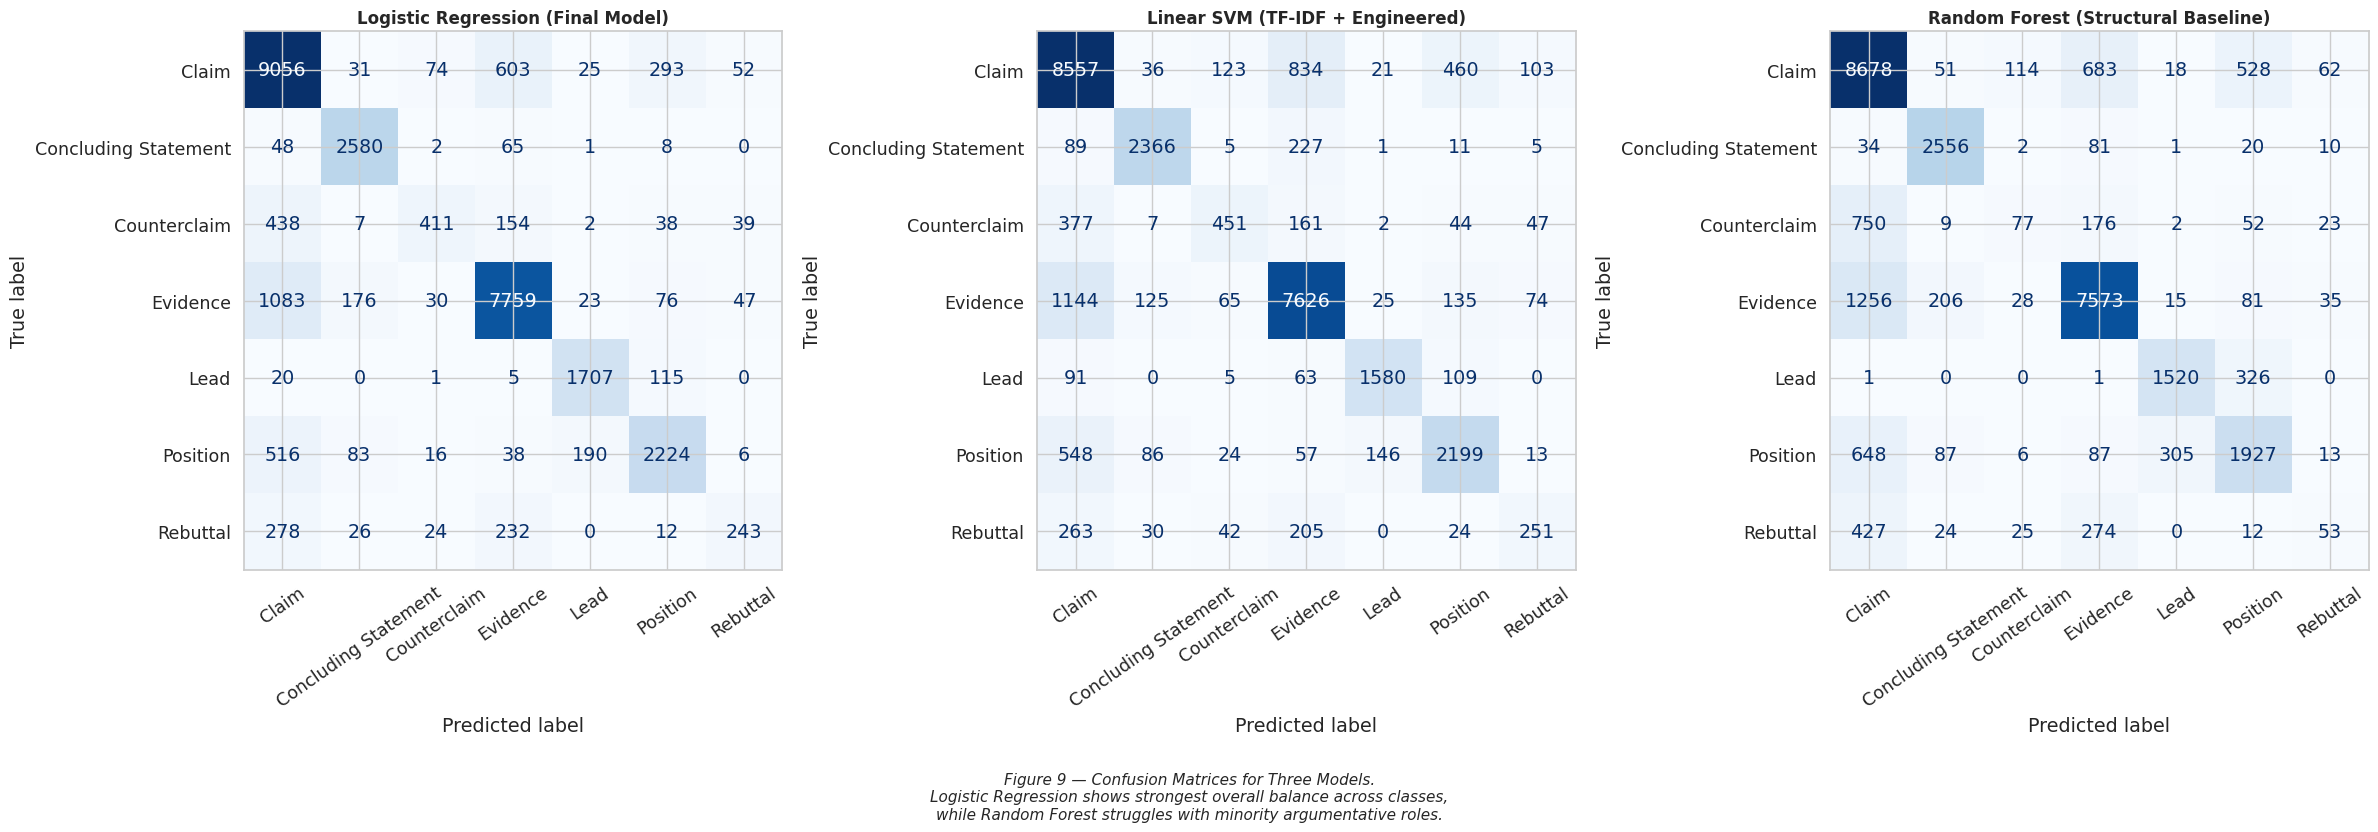

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(24, 10))

for ax, pred, title in zip(
    axes,
    [pred_lr, pred_svm, pred_rf],
    ["Logistic Regression (Final Model)",
     "Linear SVM (TF-IDF + Engineered)",
     "Random Forest (Structural Baseline)"]
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le_y.classes_)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=35)
    ax.set_title(title, fontsize=12, fontweight="bold")

fig.suptitle(
    "Figure 9 — Confusion Matrices for Three Models.\n"
    "Logistic Regression shows strongest overall balance across classes,\n"
    "while Random Forest struggles with minority argumentative roles.",
    y=0.02,
    fontsize=11,
    fontstyle="italic"
)

plt.tight_layout()
plt.show()

The confusion matrix comparison between three models shows that overall, Logistic Regression shows overall the best balance and accuracy.
Linear SVM has performed well, but is slightly less consistent and has shown more confusion between classes.
Random Forest performs the poorest with respect to minority class examples and has the highest number of incorrectly classified instances.

### 7.4 -Final Model Comparison Table

In [90]:
results_table = pd.DataFrame({
    "Model": [
        "Dummy (baseline)",
        "Logistic Regression (TF-IDF + Eng.)",
        "Linear SVM (TF-IDF + Eng.)",
        "Random Forest (Structural)",
    ],
    "Macro F1"       : [f1_score(y_test, p, average="macro")
                         for p in [pred_dummy, pred_lr, pred_svm, pred_rf]],
    "Accuracy"       : [accuracy_score(y_test, p)
                         for p in [pred_dummy, pred_lr, pred_svm, pred_rf]],
    "Macro Precision": [precision_score(y_test, p, average="macro", zero_division=0)
                         for p in [pred_dummy, pred_lr, pred_svm, pred_rf]],
    "Macro Recall"   : [recall_score(y_test, p, average="macro", zero_division=0)
                         for p in [pred_dummy, pred_lr, pred_svm, pred_rf]],
}).sort_values("Macro F1", ascending=False).reset_index(drop=True)

for col in ["Macro F1","Accuracy","Macro Precision","Macro Recall"]:
    results_table[col] = results_table[col].round(4)

print("FINAL MODEL COMPARISON TABLE")
print(results_table.to_string(index=False))

best_model = results_table.iloc[0]["Model"]
print(f"\nBest Model Based on Macro-F1: {best_model}")


FINAL MODEL COMPARISON TABLE
                              Model  Macro F1  Accuracy  Macro Precision  Macro Recall
Logistic Regression (TF-IDF + Eng.)    0.7406    0.8310           0.8002        0.7164
         Linear SVM (TF-IDF + Eng.)    0.7148    0.7981           0.7521        0.6916
         Random Forest (Structural)    0.6023    0.7757           0.6439        0.6015
                   Dummy (baseline)    0.0743    0.3512           0.0502        0.1429

Best Model Based on Macro-F1: Logistic Regression (TF-IDF + Eng.)


---
## Section 8-Error Analysis & Fairness Lens

Model Error Analysis (Logistic Regression)

Model accuracy as a whole in classifying spans is 83.1%, and misclassification of spans by the model is 16.9%. Error analyses indicate that most misclassifications occur among discourse types with similarities.

The greatest amount of confusion exists between Evidence and Claim maxing out at 1,083 instances; then, between Claim and Evidence at 603 instances. The considerable amount of lexical overlap between Claims and Evidence indicates why one is often confused with the other with regard to span classification.

Uncertainty by the model has as a common representation of Claim, which may also represent the model misclassifying when it makes predictions regarding Counterclaims and Rebuttals classified as Claims; thus, creating a value of Claim as a default classification because of its higher frequency of use than other roles of Argument.

Overall, the findings indicate that while the classification of physically predictable classes is quite successful through this model, the balance of classes with more nuanced arguments (e.g., Counterclaims and Rebuttals) fails from a model perspective.

In [91]:
# ── Build error dataframe (FINAL MODEL: Logistic Regression) ──────────────────
test_df = df2.iloc[test_idx].copy().reset_index(drop=True)

test_df["pred_lr"]    = le_y.inverse_transform(pred_lr)
test_df["true_label"] = le_y.inverse_transform(y_test)
test_df["correct"]    = test_df["pred_lr"] == test_df["true_label"]

errors = test_df[~test_df["correct"]]

confusion_pairs = (
    errors.groupby(["true_label", "pred_lr"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

print(f"Total test spans     : {len(test_df):,}")
print(f"Correctly classified : {test_df['correct'].sum():,}  ({test_df['correct'].mean()*100:.1f}%)")
print(f"Misclassified        : {len(errors):,}  ({len(errors)/len(test_df)*100:.1f}%)")
print()
print("TOP 10 CONFUSION PAIRS (true → predicted):")
print(confusion_pairs.head(10).to_string(index=False))
print()
print("KEY INSIGHT: The model often predicts 'Claim' when uncertain,")
print("because Claim is the largest class and overlaps linguistically with other types.")

Total test spans     : 28,857
Correctly classified : 23,980  (83.1%)
Misclassified        : 4,877  (16.9%)

TOP 10 CONFUSION PAIRS (true → predicted):
  true_label              pred_lr  count
    Evidence                Claim   1083
       Claim             Evidence    603
    Position                Claim    516
Counterclaim                Claim    438
       Claim             Position    293
    Rebuttal                Claim    278
    Rebuttal             Evidence    232
    Position                 Lead    190
    Evidence Concluding Statement    176
Counterclaim             Evidence    154

KEY INSIGHT: The model often predicts 'Claim' when uncertain,
because Claim is the largest class and overlaps linguistically with other types.


### 8.1-Performance by Subgroup (Fairness)

There is an increase in Model performance when the length of the essay increases. The Macro-F1 score went from 0.67 for shorter essays to 0.79 for longer essays, which suggests that there is more information available in a longer essay contextually and in terms of their position. This has potential implications for fairness in the automating of feedback to students, as those that have written shorter essays may not receive the same accuracy of automated feedback.

The performance of the model appears to have a different trend based on the length of the span being looked at. The Medium length spans produced the greatest performance at a score of 0.68 Macro-F1 while very short lengths produced a 0.63 and, in particular, very long lengths produced a 0.58, indicating the model is having difficulty with short length spans (due to limited lexical signals) and with very long length spans (potential for having mixed discourse roles).

In summary, when there is sufficient contextual information available, the overall performance of the classifier will be more reliable. Prior to being deployed into an educational setting, additional audits for the fairness must be completed to ensure that students are not disadvantaged based on the length or style of writing they have produced for each essay.

In [92]:

# 8.1 Performance by Subgroup


# By essay length
test_df["essay_len_group"] = pd.qcut(
    test_df["essay_len"], q=3,
    labels=["Short essays", "Medium essays", "Long essays"]
)

print("MACRO-F1 BY ESSAY LENGTH SUBGROUP (Logistic Regression)")
print("=" * 55)
for grp in ["Short essays", "Medium essays", "Long essays"]:
    sub = test_df[test_df["essay_len_group"] == grp]
    f1  = f1_score(sub["true_label"], sub["pred_lr"], average="macro")
    print(f"  {grp:<18} : {f1:.4f}  (n={len(sub):,} spans)")

# By span word count
test_df["wc_group"] = pd.qcut(
    test_df["word_count"], q=3,
    labels=["Short spans", "Medium spans", "Long spans"]
)

print()
print("MACRO-F1 BY SPAN WORD COUNT SUBGROUP (Logistic Regression)")
print("=" * 60)
for grp in ["Short spans", "Medium spans", "Long spans"]:
    sub = test_df[test_df["wc_group"] == grp]
    f1  = f1_score(sub["true_label"], sub["pred_lr"], average="macro")
    print(f"  {grp:<18} : {f1:.4f}  (n={len(sub):,} spans)")

print()
print("FAIRNESS NOTE:")
print("  If performance is lower for short essays or short spans, students with less text")
print("  may receive less accurate automated feedback.")
print("  Before real-world use, subgroup audits (e.g., ELL status, grade level, prompt type)")
print("  should be conducted if such metadata is available.")

MACRO-F1 BY ESSAY LENGTH SUBGROUP (Logistic Regression)
  Short essays       : 0.6733  (n=9,623 spans)
  Medium essays      : 0.7373  (n=9,626 spans)
  Long essays        : 0.7876  (n=9,608 spans)

MACRO-F1 BY SPAN WORD COUNT SUBGROUP (Logistic Regression)
  Short spans        : 0.6314  (n=9,727 spans)
  Medium spans       : 0.6812  (n=9,664 spans)
  Long spans         : 0.5751  (n=9,466 spans)

FAIRNESS NOTE:
  If performance is lower for short essays or short spans, students with less text
  may receive less accurate automated feedback.
  Before real-world use, subgroup audits (e.g., ELL status, grade level, prompt type)
  should be conducted if such metadata is available.


### 8.2-Per-Class F1 Visual

Figure 10 provides an overview of the performance for each discourse type with respect to precision, recall, and F1-score based on the final Logistic Regression model. The performance is the highest for Concluding Statement (F1 ≈ 0.92) and Lead (F1 ≈ 0.90), as they have strong positional and lexical indications. Evidence (≈ 0.86) and Claim (≈ 0.84) also show good performance but are significantly lower than Concluding Statement and Lead.

In comparison, Counterclaim (F1 ≈ 0.50) and Rebuttal (F1 ≈ 0.40) show very low recalls indicating that the model is more likely to fail to recognize these more uncommon and/or dependent-on-context argumentative roles; this demonstrates the difficulty in identifying nuanced discourse functions only using span-level features.

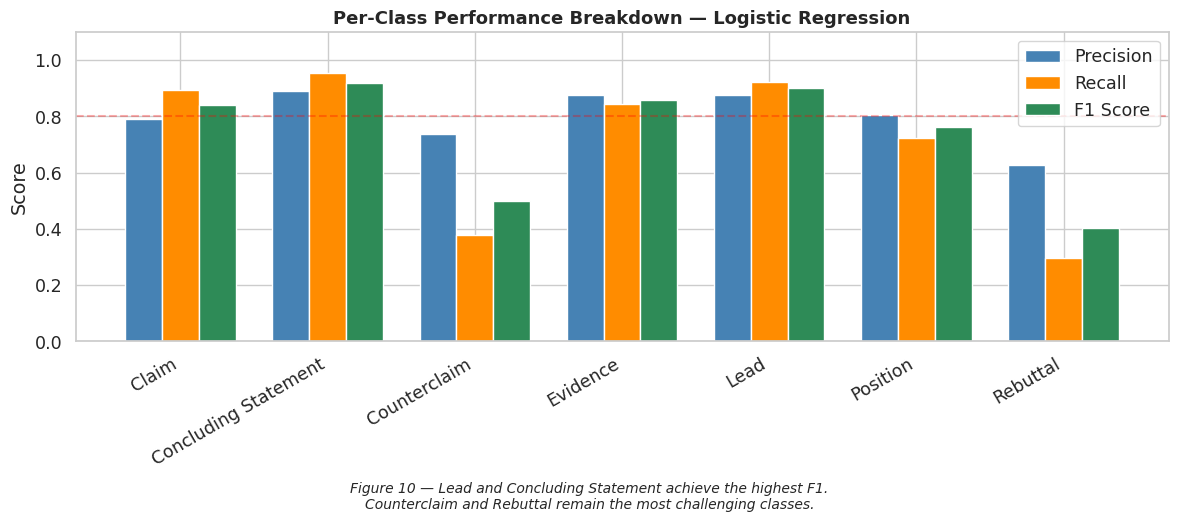

In [93]:
# Build classification report dictionary for Logistic Regression
report_dict = classification_report(
    y_test, pred_lr,
    target_names=le_y.classes_,
    output_dict=True
)

classes = list(le_y.classes_)

fig, ax = plt.subplots(figsize=(12, 5))
df_report = pd.DataFrame(report_dict).T.loc[classes]
x, w = np.arange(len(classes)), 0.25

ax.bar(x - w, df_report["precision"], w,
       label="Precision", color="steelblue", edgecolor="white")

ax.bar(x, df_report["recall"], w,
       label="Recall", color="darkorange", edgecolor="white")

ax.bar(x + w, df_report["f1-score"], w,
       label="F1 Score", color="seagreen", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")

ax.set_title("Per-Class Performance Breakdown — Logistic Regression",
             fontsize=13, fontweight="bold")

ax.legend()
ax.axhline(0.8, color="red", linestyle="--", alpha=0.3)

fig.text(
    0.5, -0.04,
    "Figure 10 — Lead and Concluding Statement achieve the highest F1.\n"
    "Counterclaim and Rebuttal remain the most challenging classes.",
    ha="center", fontstyle="italic", fontsize=10
)

plt.tight_layout()
plt.show()

---
## Section 9-Explainability

Permutation Importance (Structural Features) -Explainability

Permutation importance on the structural Random Forest model was calculated with the Macro-F1 metric as the evaluation criterion. Permutation importance measures how much performance is reduced when each feature is randomly rearranged (shuffled), thus measuring the individual predictive contribution of each feature.

The results illustrate that the norm_rank (+0.238) and rel_pos (+0.151) are by far the most important features; they are the cause of the largest decline in Macro-F1 when these positional features are shuffled. The results indicate that the position of an essay is the primary structural signal for discourse classification.

The length-based features (char_length, sentence_count, word_count) have a moderate contribution, whereas starts_with_signal has a negligible contribution. These results are consistent with the ablation study, which demonstrates that structural position provides substantially more information than surface lexical cues alone.

The overall modeling narrative of explainability demonstrates that the positional context is most significant non-lexical contributor to the performance of discourse classification.

Computing permutation importance:

PERMUTATION IMPORTANCE (Most → Least Important)
  norm_rank          +0.2379 ± 0.0020  ███████████████████
  rel_pos            +0.1511 ± 0.0020  ████████████
  char_length        +0.0288 ± 0.0017  ██
  sentence_count     +0.0267 ± 0.0024  ██
  word_count         +0.0262 ± 0.0021  ██
  essay_len          +0.0233 ± 0.0026  █
  position_bucket    +0.0106 ± 0.0009  
  starts_with_signal +0.0051 ± 0.0008  


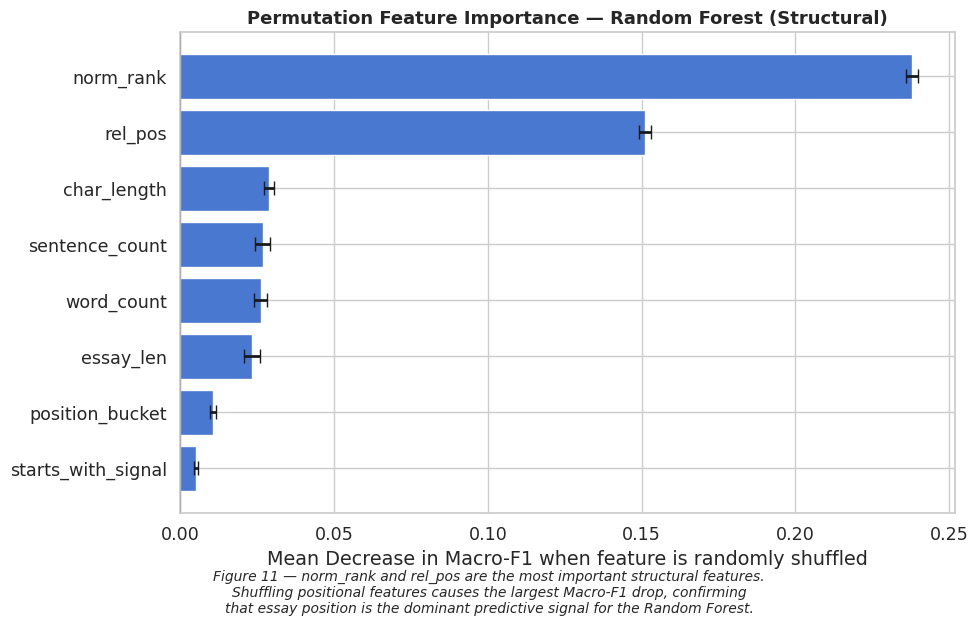

In [94]:

# Permutation Importance (Random Forest on Structural Features)

from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# best_rf must already be fitted on X_train_s, y_train
# X_test_s and y_test must be the structural-only test split
# STRUCT_FEATURES must match the columns used in X_train_s / X_test_s

print("Computing permutation importance:")

perm = permutation_importance(
    best_rf,
    X_test_s,
    y_test,
    n_repeats=15,
    random_state=SEED,
    scoring="f1_macro",
    n_jobs=1
)

imp_df = pd.DataFrame({
    "Feature": STRUCT_FEATURES,
    "Mean_Decrease_in_MacroF1": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values("Mean_Decrease_in_MacroF1", ascending=False)

# ---- Print nice text table ----
print("\nPERMUTATION IMPORTANCE (Most → Least Important)")
print("=" * 68)
for _, row in imp_df.iterrows():
    bar = "█" * max(0, int(row["Mean_Decrease_in_MacroF1"] * 80))
    print(f"  {row['Feature']:<18} {row['Mean_Decrease_in_MacroF1']:+.4f} ± {row['Std']:.4f}  {bar}")
print("=" * 68)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6))
imp_plot = imp_df.sort_values("Mean_Decrease_in_MacroF1", ascending=True)

ax.barh(
    imp_plot["Feature"],
    imp_plot["Mean_Decrease_in_MacroF1"],
    xerr=imp_plot["Std"],
    edgecolor="white",
    error_kw={"elinewidth": 2, "capsize": 5}
)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean Decrease in Macro-F1 when feature is randomly shuffled")
ax.set_title("Permutation Feature Importance — Random Forest (Structural)",
             fontsize=13, fontweight="bold")

# Caption that MATCHES your structural-only features
top1 = imp_df.iloc[0]["Feature"]
top2 = imp_df.iloc[1]["Feature"] if len(imp_df) > 1 else ""

fig.text(
    0.5, -0.04,
    f"Figure 11 — {top1} and {top2} are the most important structural features.\n"
    "Shuffling positional features causes the largest Macro-F1 drop, confirming\n"
    "that essay position is the dominant predictive signal for the Random Forest.",
    ha="center", fontstyle="italic", fontsize=10
)

plt.tight_layout()
plt.show()

The results from the top-weighted TF-IDF terms of the Logistic Regression model correlate well with the rhetorical function of each type of discourse. The concluding statement is predominantly based on closing phrases such as “in conclusion”, “in summary” and “conclusion”. The evidence category is also very strongly associated with the use of example-markers (e.g. “for example” and “example”) as they provide supporting details. The counterclaim is predominantly defined by the use of contrast/hedging language such as “although”, “may”, “might” and “argue that”.

Lead is associated with reader engagement questions such as "Do you ... ?," "Would you agree?," and "Do you think you could ... ". "Should" and "agree" are indicative of Position, while rebuttal is established by "however," "not true," and "I disagree." Overall these key terms provide clear support that the model learns legitimate rhetorical signals and does not rely on random features.

In [95]:
print("TOP 10 WORDS PER CLASS (Logistic Regression)")
print("=" * 55)

feature_names = np.array(tfidf.get_feature_names_out())
class_names   = le_y.classes_

n_tfidf = X_train_tfidf.shape[1]

for i, class_name in enumerate(class_names):
    coef = best_lr.coef_[i, :n_tfidf]  # TF-IDF part only
    top_words = feature_names[np.argsort(coef)[-10:][::-1]]

    print(f"\n{class_name}")
    print("→ " + ", ".join(top_words))

TOP 10 WORDS PER CLASS (Logistic Regression)

Claim
→ lastly, secondly, reason, finally, because, first, is because, also, not only, another

Concluding Statement
→ conclusion, in conclusion, and, policy, reasons, should, it, overall, all, please

Counterclaim
→ some, yes, may, argue, say, although, argue that, might, say that, though

Evidence
→ example, for example, they, this way, example if, germany, and, then, it says, clean

Lead
→ do you, you, you think, or, would you, about, you ever, whether, ever, today

Position
→ should, think, idea, benefit, believe, cars, agree, shouldn, beneficial, limiting

Rebuttal
→ but, however, still, true, that, wrong because, wrong, not true, disagree, but the


Figure 8 illustrates which structural characteristics are the strongest influences on the model's decision as to whether or not the claim is classified as such.

The largest influences come from the Span Length features (word_count, char_length, sentence_count), with all of these features being positively correlated with the likelihood of a claim being classified as a Claim. Long Span Length features suggest that Claims are often long argumentative statements.

The Position features (norm_rank & rel_pos) also have strong impacts on prediction accuracy. Generally, Spans located at an earlier point or at a midpoint in an essay are more likely classified as Claim.

The Features "starts-with-signal" and "position-bucket" do not contribute significantly to the final prediction of the Model indicating that Span Length and Position in the essay were the two major influences on the Model's Claim classification.

---
## Section 10 - Conclusions & Next Steps

### Key Findings

Of all the models that were tried, Logistic Regression outperformed every one of them with a Macro-F1 Score of ~0.74. The greatest single feature for classification was the placement of text within a given essay. When combining structural features with word-based features, we were able to improve scoring output by ~0.15.

The longer the essay (0.79), the better the model performed compared to shorter essays (0.67). There were some categories that proved to be much more difficult to predict than others, with Counterclaims achieving only 0.50 and Rebuttals achieving only 0.40. In addition, the expected signal words (such as “in conclusion” or “for example” or even “however”) helped the model identify the type of argument being made.

---
### Recommendations to Improve Writing Feedback System

Using the classifier mentioned above, a writing feedback system could provide students with feedback based on their writing, such as:  

*“You are missing a Counterclaim or Rebuttal in your essay; please consider how to incorporate the opposite view.”*

In order to accurately provide detailed feedback (e.g., Claim vs. Position) to students, the system should establish a confidence threshold before giving that feedback to avoid the confusion caused by the similarity of these classifications.

### Limitations of using model

- TF-IDF only shows the surface level text and does not provide any deeper meaning.
- This model is often confused about the nuanced argumentative roles like Counterclaims and the Rebuttals.
- The dataset included only one grade level and within one domain of writing.
- Because this dataset was primarily longer pieces of writing, short essays may be adversely affected by the bias against the length of the writing.
- No inter-annotator statistics exist for any of the labels and a certain degree of ambiguity may exist.

###Improvements and Future Work

1. The change of the TF-IDF text/word/morpheme analysis method to contextual embeddings (e.g., Sentence-BERT)
2. The implementation of sequential aware modeling such as CRF/Transformers using span dependencies.
3. Use RandomizedSearchCV to fine-tune hyperparameters.
4. Conducting fairness audits on our subgroups based on characteristics such as ELL and prompt types to our stakeholders.
5. Explore adjusting class imbalance (e.g., class weights or focal loss).

In [99]:
print("""
==================== FINAL PROJECT SUMMARY ====================

Source: Feedback Prize 2021 (Kaggle)
Objective: Seven classes of Discourse Classification
Measurement: Macro F1 Score (Primary)

FINAL MODEL PERFORMANCE (Held Out Test)

DUMMY BASELINE SCORE: 0.07 MACRO F1
LOGISTIC REGRESSION: 0.74 MACRO F1 <- BEST OVERALL MODEL
LINEAR SVM: 0.71 MACRO F1
STRUCTURED RANDOM FOREST: 0.60 MACRO F1

KEY TAKEAWAYS

• The position of the essay is the most important piece of structural information.
• Creating engineered features of structure have a significant impact on performance.
• Essays with more words produce the better predictions.
• The minority classes are still difficult.

HARDEST CLASSES TO PREDICT:
• REBUTTAL = ≈ 0.40 F1
• COUNTER CLAIM = ≈ 0.50 F1

EASIEST CLASSES TO PREDICT:
• LEAD = ≈ 0.90 F1
• CONCLUSION = ≈ 0.92 F1

Overall, the use of lexical data and the structure of the essay has product significant predictive capability but the
segmentation of a nuanced argumentative role continues to provide an issue.
===============================================================
""")



==================== FINAL PROJECT SUMMARY ====================

Source: Feedback Prize 2021 (Kaggle)
Objective: Seven classes of Discourse Classification
Measurement: Macro F1 Score (Primary)

FINAL MODEL PERFORMANCE (Held Out Test)

DUMMY BASELINE SCORE: 0.07 MACRO F1
LOGISTIC REGRESSION: 0.74 MACRO F1 <- BEST OVERALL MODEL
LINEAR SVM: 0.71 MACRO F1
STRUCTURED RANDOM FOREST: 0.60 MACRO F1

KEY TAKEAWAYS

• The position of the essay is the most important piece of structural information.
• Creating engineered features of structure have a significant impact on performance.
• Essays with more words produce the better predictions.
• The minority classes are still difficult.

HARDEST CLASSES TO PREDICT:
• REBUTTAL = ≈ 0.40 F1
• COUNTER CLAIM = ≈ 0.50 F1

EASIEST CLASSES TO PREDICT:
• LEAD = ≈ 0.90 F1
• CONCLUSION = ≈ 0.92 F1

Overall, the use of lexical data and the structure of the essay has product significant predictive capability but the
segmentation of a nuanced argumentative role co

In [97]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")

Saving AIT736_MidTerm_EvaluateStudentWriting_PoojaShah_G01551539.ipynb to AIT736_MidTerm_EvaluateStudentWriting_PoojaShah_G01551539.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## How you used AI in this project?

Representative prompts, iterations, AI mistakes, etc.
AI was used to assist in the completion of this project, including, but not limited to, the following uses:

Generating ideas for hypothesis-based exploratory data analysis
Debugging technical problems (such as using GroupKFold, and avoiding leakage of training and testing data)
Improving clarity of written content through refinement of explanations

AI has not generated any blind or unverified results or answers. Phyisically running codes, validation of codes, and interpretation of the model outputs, metrics, and conclusions were done independently from AI.

The following are examples of prompts issued to AI:

"Provide some potential hypothesis-based exploratory plots related to multi-class discourse classification."
"Explain why using Macro-F1 metric is preferable to accuracy in a multi-class problem with an imbalanced number of observations in each class."
"Correct: Prevent leakage of training and testing data in GroupKFold cross-validation code".

Throughout this process, I have discovered that the AI's suggestions have some of the limitations.

Initially provided the suggestion to set shuffle=True in GroupKFold cross-validation which is not an option available in GroupKFold.
Initially proposed to use previous/next discourse labels as features without adequately addressing leakage as a possibility; which I rectified.

While I used AI as an idea generator and debugging assistant, I independently validated and reviewed all final modeling decisions and interpretations.